In [ ]:
from google.colab import files
import pandas as pd

# 파일 업로드
uploaded = files.upload()

# 업로드된 파일을 pandas로 읽기
file_name = list(uploaded.keys())[0]
data = pd.read_csv(file_name, encoding='euc-kr')  # 인코딩 필요 시 명시
print(len(data))  # 데이터의 총 행 수를 확인
print(data)       # 전체 데이터 출력

Saving 경찰청 인천광역시경찰청_관서별 5대범죄 발생 및 검거 건수_20231231.csv to 경찰청 인천광역시경찰청_관서별 5대범죄 발생 및 검거 건수_20231231 (1).csv
10
        구분 발생검거   중부서  미추홀서   남동서   부평서   서부서   계양서  강화서   연수서   삼산서  논현서
0       살인   발생     1     7     8     1     5     3    2     5     3    4
1       살인   검거     2     4     8     1     4     3    2     4     3    3
2       강도   발생     3    11    13    14     3     7    1     5     3    0
3       강도   검거     2     8    14    17     3    10    1     4     3    0
4  강간.강제추행   발생   111   253   171    98   238   112   18   124   184   61
5  강간.강제추행   검거    75   220   151    86   199   102    0   100   163   54
6       절도   발생   874  1653   894  1089  1298   737  170  1235  1110  507
7       절도   검거   511  1216   802   780  1057   569   96  1013   833  361
8       폭력   발생  1351  2298  1377  1291  2718  1293  337  1440  1567  831
9       폭력   검거  1096  2093  1251  1166  2246  1100  293  1295  1399  733


통계량 요약 (폭력):
             검거 건수        발생 건수      검거 비율
count    10.000000    10.000000  10.000000
mean   1267.200000  1450.300000   0.875439
std     573.521636   668.971524   0.035282
min     293.000000   337.000000   0.811251
25%    1097.000000  1291.500000   0.855410
50%    1208.500000  1364.000000   0.887429
75%    1373.000000  1535.250000   0.902208
max    2246.000000  2718.000000   0.910792


<ipython-input-17-34354a045f80>:45: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from current font.
  plt.tight_layout()
<ipython-input-17-34354a045f80>:45: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from current font.
  plt.tight_layout()
<ipython-input-17-34354a045f80>:45: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from current font.
  plt.tight_layout()
<ipython-input-17-34354a045f80>:45: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-17-34354a045f80>:45: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from current font.
  plt.tight_layout()
<ipython-input-17-34354a045f80>:45: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from current font.
  plt.tight_layout()
<ipython-input-17-34354a045f80>:45: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from current font.
  plt.tight_layout()
<ipython-input-17-34354a045f80>:45: UserWarning: Gly

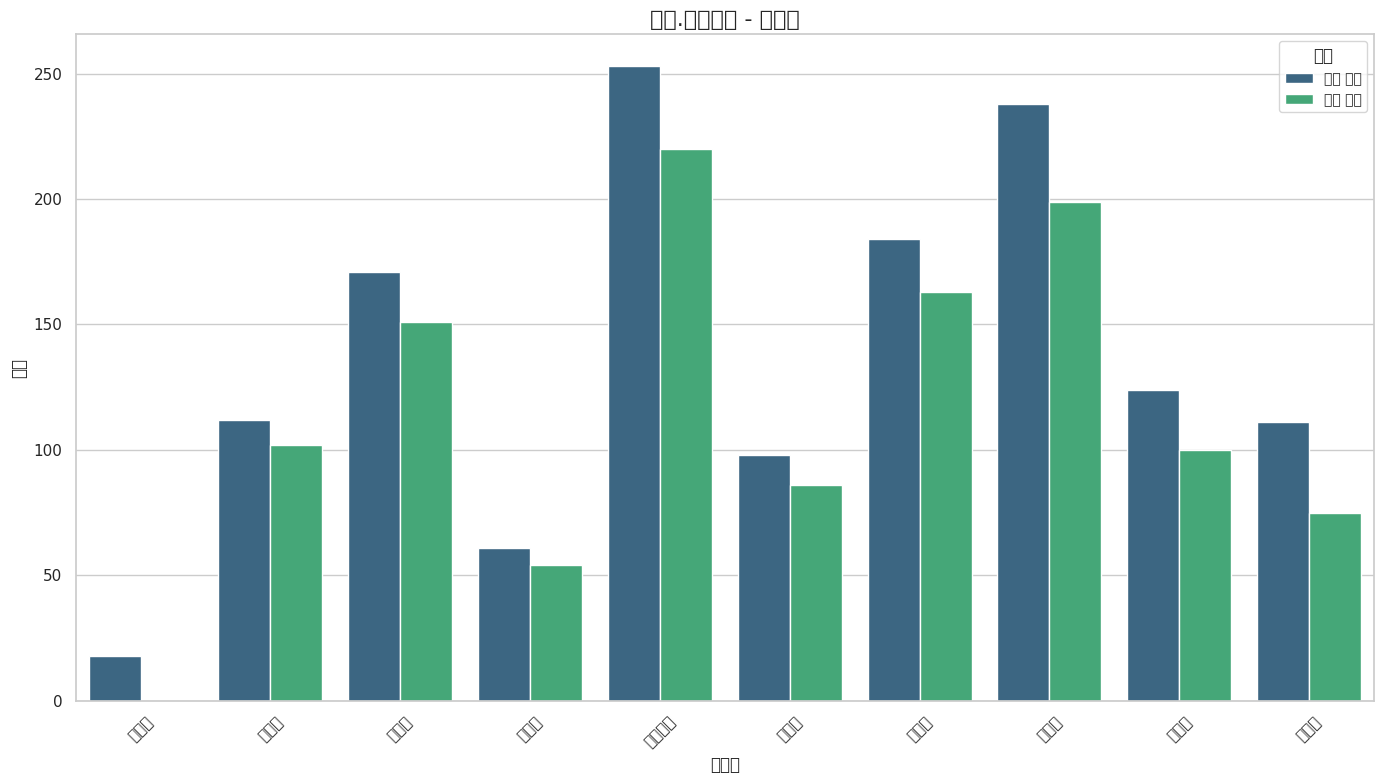

In [ ]:
import matplotlib.font_manager as fm
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'

# '구분'과 '발생검거' 열을 기준으로 발생과 검거 건수를 길게 변환
data_melted = pd.melt(data, id_vars=["구분", "발생검거"], var_name="경찰서", value_name="건수")

# '발생'과 '검거'를 분리하여 시각화를 준비
data_pivoted = data_melted.pivot_table(index=["구분", "경찰서"], columns="발생검거", values="건수", fill_value=0).reset_index()
data_pivoted.columns.name = None  # MultiIndex 제거
data_pivoted.rename(columns={"발생": "발생 건수", "검거": "검거 건수"}, inplace=True)

# 시각화: 경찰서별 5대 범죄 발생 및 검거 건수 비교
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# describe 통계량 출력
print(f"통계량 요약 ({crime_type}):")
print(filtered_data.describe())


# 범죄 유형을 선택하여 시각화 (예: 강간.강제추행)
crime_type = "강간.강제추행"  # 범죄 유형을 변경할 수 있습니다.
filtered_data = data_pivoted[data_pivoted["구분"] == crime_type]

# 막대 그래프 생성
sns.barplot(
    data=filtered_data.melt(id_vars=["경찰서"], value_vars=["발생 건수", "검거 건수"], var_name="유형", value_name="건수"),
    x="경찰서",
    y="건수",
    hue="유형",
    palette="viridis"
)

# 그래프 꾸미기
plt.title(f"{crime_type} - 관서별", fontsize=16)
plt.xlabel("경찰서", fontsize=12)
plt.ylabel("건수", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="유형", fontsize=10)
plt.tight_layout()
plt.show()

<ipython-input-11-1074f2b6b29f>:44: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from current font.
  plt.tight_layout()
<ipython-input-11-1074f2b6b29f>:44: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from current font.
  plt.tight_layout()
<ipython-input-11-1074f2b6b29f>:44: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from current font.
  plt.tight_layout()
<ipython-input-11-1074f2b6b29f>:44: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-11-1074f2b6b29f>:44: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from current font.
  plt.tight_layout()
<ipython-input-11-1074f2b6b29f>:44: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from current font.
  plt.tight_layout()
<ipython-input-11-1074f2b6b29f>:44: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from current font.
  plt.tight_layout()
<ipython-input-11-1074f2b6b29f>:44: UserWarning: Gly

통계량 요약 (살인):
           검거 건수      발생 건수
count  10.000000  10.000000
mean    3.400000   3.900000
std     1.897367   2.378141
min     1.000000   1.000000
25%     2.250000   2.250000
50%     3.000000   3.500000
75%     4.000000   5.000000
max     8.000000   8.000000


<ipython-input-11-1074f2b6b29f>:44: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from current font.
  plt.tight_layout()
<ipython-input-11-1074f2b6b29f>:44: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  

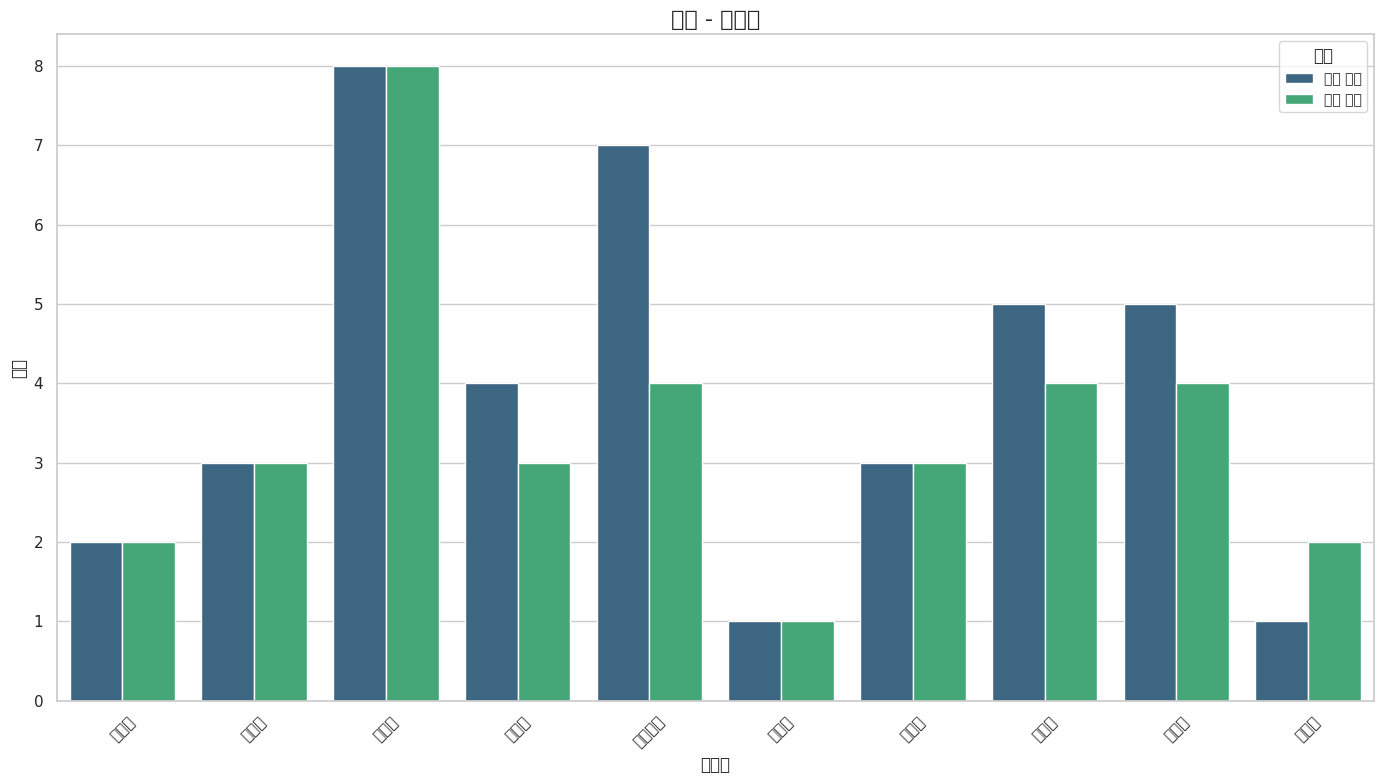

In [ ]:
import matplotlib.font_manager as fm
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# '구분'과 '발생검거' 열을 기준으로 발생과 검거 건수를 길게 변환
data_melted = pd.melt(data, id_vars=["구분", "발생검거"], var_name="경찰서", value_name="건수")

# '발생'과 '검거'를 분리하여 시각화를 준비
data_pivoted = data_melted.pivot_table(index=["구분", "경찰서"], columns="발생검거", values="건수", fill_value=0).reset_index()
data_pivoted.columns.name = None  # MultiIndex 제거
data_pivoted.rename(columns={"발생": "발생 건수", "검거": "검거 건수"}, inplace=True)0

# 시각화: 경찰서별 5대 범죄 발생 및 검거 건수 비교
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# 범죄 유형을 선택하여 시각화
crime_type = "살인"  # 범죄 유형을 변경할 수 있습니다.
filtered_data = data_pivoted[data_pivoted["구분"] == crime_type]

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'

# 막대 그래프 생성
sns.barplot(
    data=filtered_data.melt(id_vars=["경찰서"], value_vars=["발생 건수", "검거 건수"], var_name="유형", value_name="건수"),
    x="경찰서",
    y="건수",
    hue="유형",
    palette="viridis"
)

# describe 통계량 출력
print(f"통계량 요약 ({crime_type}):")
print(filtered_data.describe())

# 그래프 꾸미기
plt.title(f"{crime_type} - 관서별", fontsize=16)
plt.xlabel("경찰서", fontsize=12)
plt.ylabel("건수", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="유형", fontsize=10)
plt.tight_layout()
plt.show()

<ipython-input-12-6a1728343aae>:45: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from current font.
  plt.tight_layout()
<ipython-input-12-6a1728343aae>:45: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from current font.
  plt.tight_layout()
<ipython-input-12-6a1728343aae>:45: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from current font.
  plt.tight_layout()
<ipython-input-12-6a1728343aae>:45: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-12-6a1728343aae>:45: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from current font.
  plt.tight_layout()
<ipython-input-12-6a1728343aae>:45: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from current font.
  plt.tight_layout()
<ipython-input-12-6a1728343aae>:45: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from current font.
  plt.tight_layout()
<ipython-input-12-6a1728343aae>:45: UserWarning: Gly

통계량 요약 (강도):
          검거 건수      발생 건수
count  10.00000  10.000000
mean    6.20000   6.000000
std     5.80804   5.033223
min     0.00000   0.000000
25%     2.25000   3.000000
50%     3.50000   4.000000
75%     9.50000  10.000000
max    17.00000  14.000000


<ipython-input-12-6a1728343aae>:45: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from current font.
  plt.tight_layout()
<ipython-input-12-6a1728343aae>:45: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  

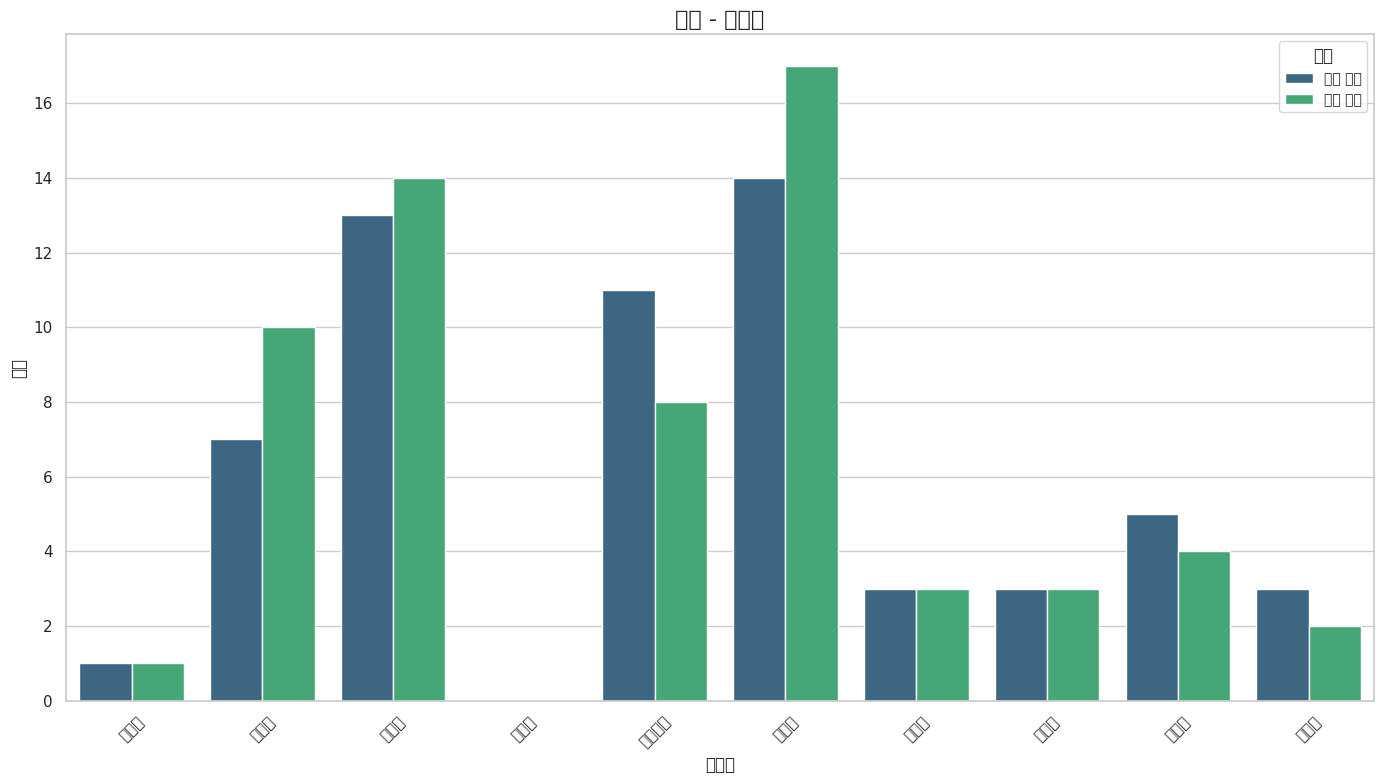

In [ ]:
import matplotlib.font_manager as fm
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# '구분'과 '발생검거' 열을 기준으로 발생과 검거 건수를 길게 변환
data_melted = pd.melt(data, id_vars=["구분", "발생검거"], var_name="경찰서", value_name="건수")

# '발생'과 '검거'를 분리하여 시각화를 준비
data_pivoted = data_melted.pivot_table(index=["구분", "경찰서"], columns="발생검거", values="건수", fill_value=0).reset_index()
data_pivoted.columns.name = None  # MultiIndex 제거
data_pivoted.rename(columns={"발생": "발생 건수", "검거": "검거 건수"}, inplace=True)

# 시각화: 경찰서별 5대 범죄 발생 및 검거 건수 비교
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# 범죄 유형을 선택하여 시각화
crime_type = "강도"  # 범죄 유형을 변경할 수 있습니다.
filtered_data = data_pivoted[data_pivoted["구분"] == crime_type]

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'

# 막대 그래프 생성
sns.barplot(
    data=filtered_data.melt(id_vars=["경찰서"], value_vars=["발생 건수", "검거 건수"], var_name="유형", value_name="건수"),
    x="경찰서",
    y="건수",
    hue="유형",
    palette="viridis"
)
# describe 통계량 출력
print(f"통계량 요약 ({crime_type}):")
print(filtered_data.describe())



# 그래프 꾸미기
plt.title(f"{crime_type} - 관서별", fontsize=16)
plt.xlabel("경찰서", fontsize=12)
plt.ylabel("건수", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="유형", fontsize=10)
plt.tight_layout()
plt.show()

<ipython-input-13-8792c41891b6>:44: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from current font.
  plt.tight_layout()
<ipython-input-13-8792c41891b6>:44: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from current font.
  plt.tight_layout()
<ipython-input-13-8792c41891b6>:44: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from current font.
  plt.tight_layout()
<ipython-input-13-8792c41891b6>:44: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-13-8792c41891b6>:44: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from current font.
  plt.tight_layout()
<ipython-input-13-8792c41891b6>:44: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from current font.
  plt.tight_layout()
<ipython-input-13-8792c41891b6>:44: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from current font.
  plt.tight_layout()
<ipython-input-13-8792c41891b6>:44: UserWarning: Gly

통계량 요약 (절도):
             검거 건수        발생 건수
count    10.000000    10.000000
mean    723.800000   956.700000
std     342.072377   421.629129
min      96.000000   170.000000
25%     525.500000   771.250000
50%     791.000000   991.500000
75%     968.000000  1203.750000
max    1216.000000  1653.000000


<ipython-input-13-8792c41891b6>:44: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from current font.
  plt.tight_layout()
<ipython-input-13-8792c41891b6>:44: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from current font.
  plt.tight_layout()
<ipython-input-13-8792c41891b6>:44: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from current font.
  plt.tight_layout()
<ipython-input-13-8792c41891b6>:44: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from current font.
  plt.tight_layout()
<ipython-input-13-8792c41891b6>:44: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from current font.
  plt.tight_layout()
<ipython-input-13-8792c41891b6>:44: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from current font.
  plt.tight_layout()
<ipython-input-13-8792c41891b6>:44: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from current font.
  plt.tight_layout()
<ipython-input-13-8792c41891b6>:44: UserWarning: 

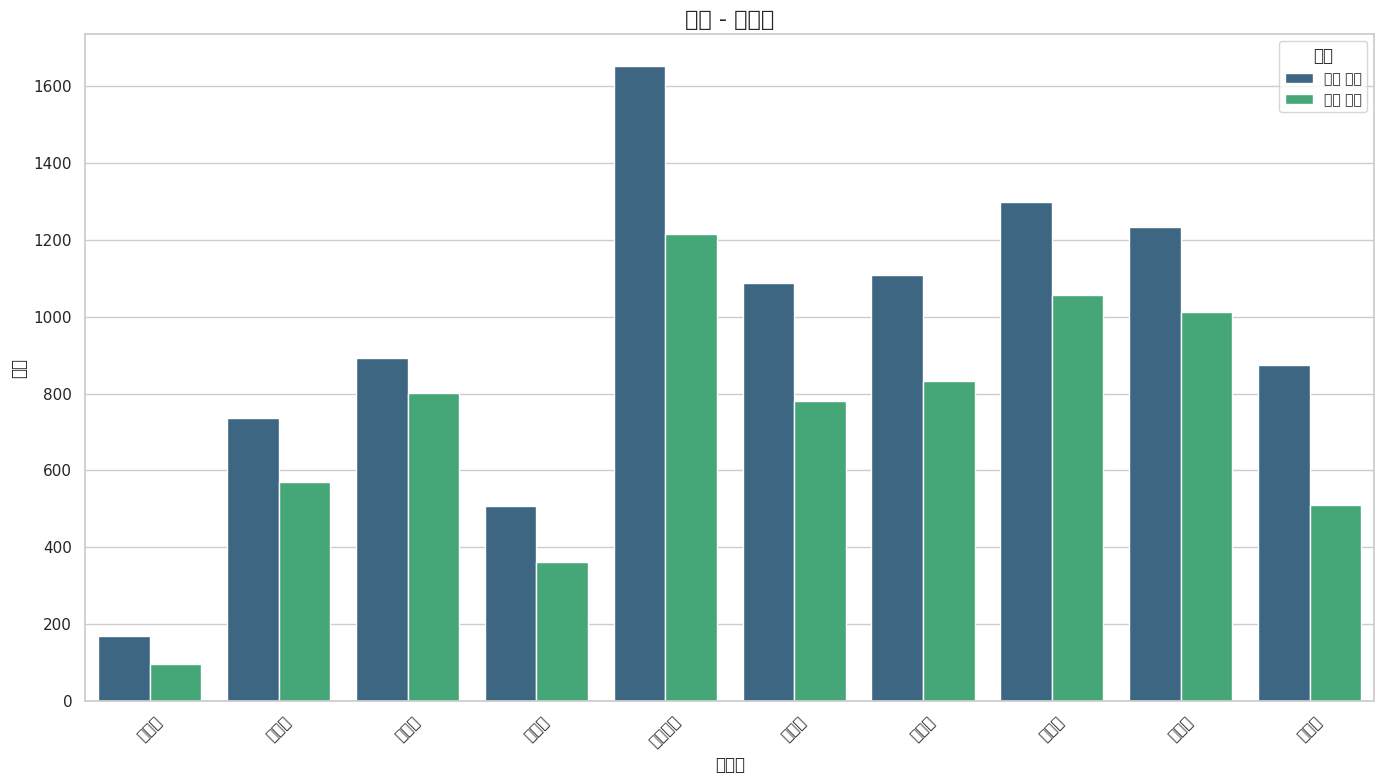

In [ ]:
import matplotlib.font_manager as fm
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# '구분'과 '발생검거' 열을 기준으로 발생과 검거 건수를 길게 변환
data_melted = pd.melt(data, id_vars=["구분", "발생검거"], var_name="경찰서", value_name="건수")

# '발생'과 '검거'를 분리하여 시각화를 준비
data_pivoted = data_melted.pivot_table(index=["구분", "경찰서"], columns="발생검거", values="건수", fill_value=0).reset_index()
data_pivoted.columns.name = None  # MultiIndex 제거
data_pivoted.rename(columns={"발생": "발생 건수", "검거": "검거 건수"}, inplace=True)

# 시각화: 경찰서별 5대 범죄 발생 및 검거 건수 비교
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# 범죄 유형을 선택하여 시각화
crime_type = "절도"  # 범죄 유형을 변경할 수 있습니다.
filtered_data = data_pivoted[data_pivoted["구분"] == crime_type]


# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'

# 막대 그래프 생성
sns.barplot(
    data=filtered_data.melt(id_vars=["경찰서"], value_vars=["발생 건수", "검거 건수"], var_name="유형", value_name="건수"),
    x="경찰서",
    y="건수",
    hue="유형",
    palette="viridis"
)
# describe 통계량 출력
print(f"통계량 요약 ({crime_type}):")
print(filtered_data.describe())

# 그래프 꾸미기
plt.title(f"{crime_type} - 관서별", fontsize=16)
plt.xlabel("경찰서", fontsize=12)
plt.ylabel("건수", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="유형", fontsize=10)
plt.tight_layout()
plt.show()

<ipython-input-14-e92706adf07f>:45: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from current font.
  plt.tight_layout()
<ipython-input-14-e92706adf07f>:45: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from current font.
  plt.tight_layout()
<ipython-input-14-e92706adf07f>:45: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from current font.
  plt.tight_layout()
<ipython-input-14-e92706adf07f>:45: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-14-e92706adf07f>:45: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from current font.
  plt.tight_layout()
<ipython-input-14-e92706adf07f>:45: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from current font.
  plt.tight_layout()
<ipython-input-14-e92706adf07f>:45: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from current font.
  plt.tight_layout()
<ipython-input-14-e92706adf07f>:45: UserWarning: Gly

통계량 요약 (폭력):
             검거 건수        발생 건수
count    10.000000    10.000000
mean   1267.200000  1450.300000
std     573.521636   668.971524
min     293.000000   337.000000
25%    1097.000000  1291.500000
50%    1208.500000  1364.000000
75%    1373.000000  1535.250000
max    2246.000000  2718.000000


<ipython-input-14-e92706adf07f>:45: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from current font.
  plt.tight_layout()
<ipython-input-14-e92706adf07f>:45: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  

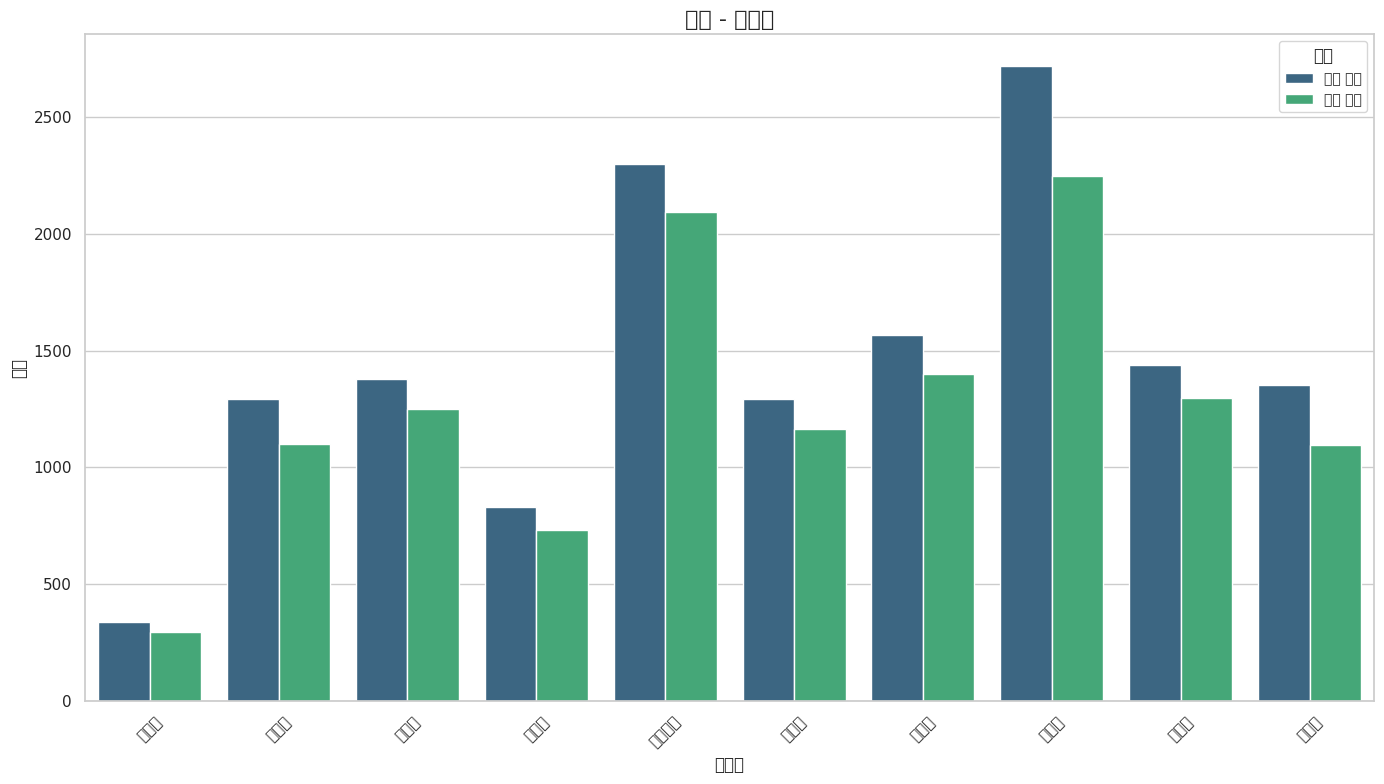

In [ ]:
import matplotlib.font_manager as fm
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# '구분'과 '발생검거' 열을 기준으로 발생과 검거 건수를 길게 변환
data_melted = pd.melt(data, id_vars=["구분", "발생검거"], var_name="경찰서", value_name="건수")

# '발생'과 '검거'를 분리하여 시각화를 준비
data_pivoted = data_melted.pivot_table(index=["구분", "경찰서"], columns="발생검거", values="건수", fill_value=0).reset_index()
data_pivoted.columns.name = None  # MultiIndex 제거
data_pivoted.rename(columns={"발생": "발생 건수", "검거": "검거 건수"}, inplace=True)

# 시각화: 경찰서별 5대 범죄 발생 및 검거 건수 비교
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# 범죄 유형을 선택하여 시각화
crime_type = "폭력"  # 범죄 유형을 변경할 수 있습니다.
filtered_data = data_pivoted[data_pivoted["구분"] == crime_type]


# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'

# 막대 그래프 생성
sns.barplot(
    data=filtered_data.melt(id_vars=["경찰서"], value_vars=["발생 건수", "검거 건수"], var_name="유형", value_name="건수"),
    x="경찰서",
    y="건수",
    hue="유형",
    palette="viridis"
)
# describe 통계량 출력
print(f"통계량 요약 ({crime_type}):")
print(filtered_data.describe())


# 그래프 꾸미기
plt.title(f"{crime_type} - 관서별", fontsize=16)
plt.xlabel("경찰서", fontsize=12)
plt.ylabel("건수", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="유형", fontsize=10)
plt.tight_layout()
plt.show()

<ipython-input-16-ec5328259106>:81: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from current font.
  plt.tight_layout()
<ipython-input-16-ec5328259106>:81: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from current font.
  plt.tight_layout()
<ipython-input-16-ec5328259106>:81: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from current font.
  plt.tight_layout()
<ipython-input-16-ec5328259106>:81: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from current font.
  plt.tight_layout()
<ipython-input-16-ec5328259106>:81: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from current font.
  plt.tight_layout()
<ipython-input-16-ec5328259106>:81: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from current font.
  plt.tight_layout()
<ipython-input-16-ec5328259106>:81: UserWarning: Glyph 49332 (\N{HANGUL SYLLABLE SAL}) missing from current font.
  plt.tight_layout()
<ipython-input-16-ec5328259106>:81: UserWarning: Glyph 

     범죄 유형 가장 큰 비율 경찰서 가장 작은 비율 경찰서   가장 큰 비율  가장 작은 비율
0  강간.강제추행         계양서          강화서  0.910714  0.000000
1       강도         계양서          중부서  1.428571  0.666667
2       살인         중부서         미추홀서  2.000000  0.571429
3       절도         남동서          강화서  0.897092  0.564706
4       폭력        미추홀서          중부서  0.910792  0.811251
통계량 요약 (폭력):
             검거 건수        발생 건수      검거 비율
count    10.000000    10.000000  10.000000
mean   1267.200000  1450.300000   0.875439
std     573.521636   668.971524   0.035282
min     293.000000   337.000000   0.811251
25%    1097.000000  1291.500000   0.855410
50%    1208.500000  1364.000000   0.887429
75%    1373.000000  1535.250000   0.902208
max    2246.000000  2718.000000   0.910792


<ipython-input-16-ec5328259106>:81: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from current font.
  plt.tight_layout()
<ipython-input-16-ec5328259106>:81: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from current font.
  plt.tight_layout()
<ipython-input-16-ec5328259106>:81: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from current font.
  plt.tight_layout()
<ipython-input-16-ec5328259106>:81: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from current font.
  plt.tight_layout()
<ipython-input-16-ec5328259106>:81: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from current font.
  plt.tight_layout()
<ipython-input-16-ec5328259106>:81: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from current font.
  plt.tight_layout()
<ipython-input-16-ec5328259106>:81: UserWarning: Glyph 48143 (\N{HANGUL SYLLABLE MIC}) missing from current font.
  plt.tight_layout()
<ipython-input-16-ec5328259106>:81: UserWarning: Glyp

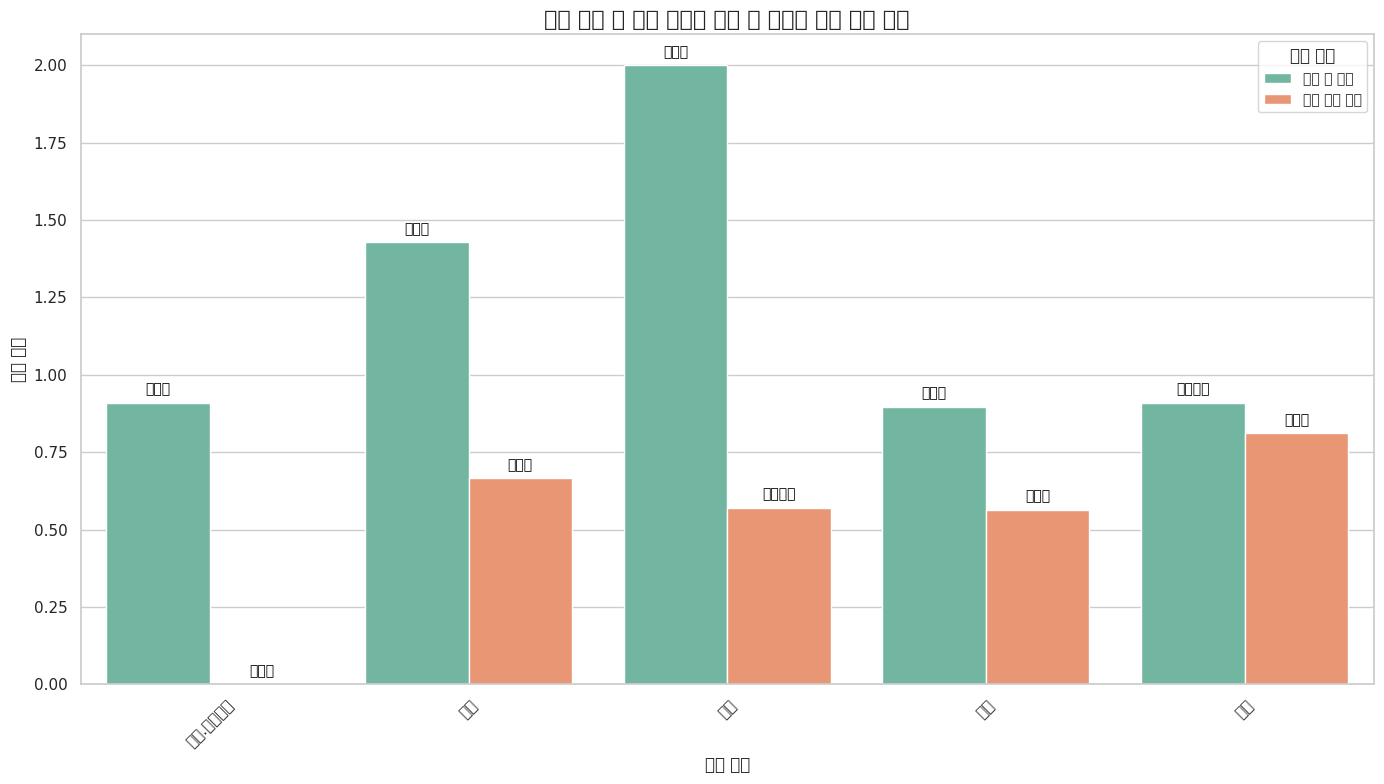

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# '구분'과 '발생검거' 열을 기준으로 발생과 검거 건수를 길게 변환
data_melted = pd.melt(data, id_vars=["구분", "발생검거"], var_name="경찰서", value_name="건수")

# '발생'과 '검거'를 분리하여 시각화를 준비
data_pivoted = data_melted.pivot_table(index=["구분", "경찰서"], columns="발생검거", values="건수", fill_value=0).reset_index()
data_pivoted.columns.name = None  # MultiIndex 제거
data_pivoted.rename(columns={"발생": "발생 건수", "검거": "검거 건수"}, inplace=True)

# 발생 건수와 검거 건수의 비율 계산
data_pivoted["검거 비율"] = data_pivoted["검거 건수"] / data_pivoted["발생 건수"]

# 각 범죄 유형별로 가장 큰 비율과 가장 작은 비율이 나온 경찰서 찾기
crime_types = data_pivoted["구분"].unique()
max_min_ratios = []

for crime_type in crime_types:
    # 각 범죄 유형에 대한 데이터를 필터링
    filtered_data = data_pivoted[data_pivoted["구분"] == crime_type]

    # 검거 비율이 가장 큰 경찰서와 가장 작은 경찰서 찾기
    max_ratio_row = filtered_data.loc[filtered_data["검거 비율"].idxmax()]
    min_ratio_row = filtered_data.loc[filtered_data["검거 비율"].idxmin()]

    # 결과 저장
    max_min_ratios.append({
        "범죄 유형": crime_type,
        "가장 큰 비율 경찰서": max_ratio_row["경찰서"],
        "가장 작은 비율 경찰서": min_ratio_row["경찰서"],
        "가장 큰 비율": max_ratio_row["검거 비율"],
        "가장 작은 비율": min_ratio_row["검거 비율"]
    })


# 결과를 데이터프레임으로 변환
max_min_ratios_df = pd.DataFrame(max_min_ratios)

# 결과 출력
print(max_min_ratios_df)

# 시각화: 가장 큰 비율과 가장 작은 비율을 비교하는 막대 그래프
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'

# 데이터 준비: 가장 큰 비율과 작은 비율 데이터
max_min_ratios_melted = max_min_ratios_df.melt(id_vars=["범죄 유형"], value_vars=["가장 큰 비율", "가장 작은 비율"],
                                              var_name="비율 종류", value_name="비율")

# 그래프 생성
sns.barplot(data=max_min_ratios_melted, x="범죄 유형", y="비율", hue="비율 종류", palette="Set2")

# 각 바 위에 경찰서 이름 추가
for i, row in max_min_ratios_df.iterrows():
    # '가장 큰 비율' 바 위에 지역 이름 추가
    plt.annotate(f'{row["가장 큰 비율 경찰서"]}',
                 xy=(i - 0.2, row["가장 큰 비율"]),
                 xytext=(i - 0.2, row["가장 큰 비율"] + 0.03),  # 막대 위에 값을 올려서 위치 조정
                 ha='center', fontsize=10, color='black', fontweight='bold')

    # '가장 작은 비율' 바 위에 지역 이름 추가
    plt.annotate(f'{row["가장 작은 비율 경찰서"]}',
                 xy=(i + 0.2, row["가장 작은 비율"]),  # 두 번째 막대 위치 조정
                 xytext=(i + 0.2, row["가장 작은 비율"] + 0.03),  # 위치 조정
                 ha='center', fontsize=10, color='black', fontweight='bold')

# describe 통계량 출력
print(f"통계량 요약 ({crime_type}):")
print(filtered_data.describe())

# 그래프 꾸미기
plt.title("범죄 발생 및 검거 비율이 가장 큰 지역과 작은 지역 비교", fontsize=16)
plt.xlabel("범죄 유형", fontsize=12)
plt.ylabel("검거 비율", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="비율 종류", fontsize=10)
plt.tight_layout()
plt.show()